![ITQ](imgLogo.png)
![ITQ](imgPortada.png)

Luis Pilaguano

# Ejercicio_CNN

### 1 Convolutional Neural Networks 
### 2 Importar Librerías

In [76]:
import numpy as np
import os
import re
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [77]:
import keras
from keras.utils import to_categorical
from keras.models import Sequential, Model
from keras.layers import Input
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.layers import BatchNormalization
from keras.layers import LeakyReLU
from keras import optimizers


### 3 Cargar set de Imágenes

In [83]:
dirname = os.path.join(os.getcwd(), 'sportimages')
imgpath = dirname + os.sep
images = []
directories = []
dircount = []
prevRoot = ''
cant = 0

print("Leyendo imágenes de", imgpath)

for root, dirnames, filenames in os.walk(imgpath):
    for filename in filenames:
        if re.search(r"\.(jpg|jpeg|png|bmp|tiff)$", filename):
            cant += 1
            filepath = os.path.join(root, filename)
            image = plt.imread(filepath)
            images.append(image)
            b = "Leyendo..." + str(cant)
            print(b, end="\r")

    if prevRoot != root:
        print(root, cant)
        prevRoot = root
        directories.append(root)
        dircount.append(cant)
        cant = 0

dircount.append(cant)
dircount = dircount[1:]
#dircount[0] = dircount[0] + 1

print('Directorios leídos:', len(directories))
print("Imágenes en cada directorio:", dircount)
print('Suma total de imágenes en subdirs:', sum(dircount))


Leyendo imágenes de C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\ 0
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\americano 9348
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\basket 8823
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\beisball 7752
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\boxeo 7125
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\ciclismo 7533
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\f1 5053
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\futbol 7617
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\golf 9768
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\natacion 5172
C:\Users\USER\Desktop\MachineLearning2\Parcial3\sportimages\tenis 8937
Directorios leídos: 11
Imágenes en cada directorio: [9348, 8823, 7752, 7125, 7533, 5053, 7617, 9768, 5172, 8937, 0]
Suma total de imáge

### 4 Creamos las etiquetas

In [84]:
labels = []
indice = 0

for cantidad in dircount:
    for i in range(cantidad):
        labels.append(indice)
    indice += 1

print("Cantidad etiquetas creadas:", len(labels))



Cantidad etiquetas creadas: 77128


In [85]:
deportes = []
indice = 0

for directorio in directories:
    name = directorio.split(os.sep)
    print(indice, name[len(name) - 1])
    deportes.append(name[len(name) - 1])
    indice += 1


0 
1 americano
2 basket
3 beisball
4 boxeo
5 ciclismo
6 f1
7 futbol
8 golf
9 natacion
10 tenis


In [86]:
y = np.array(labels)
X = np.array(images, dtype=np.uint8)  # convierto de lista a numpy

# Encuentro los números únicos de las etiquetas
classes = np.unique(y)
nClasses = len(classes)

print('Total number of outputs:', nClasses)
print('Output classes:', classes)


Total number of outputs: 10
Output classes: [0 1 2 3 4 5 6 7 8 9]


### 5 Creamos Sets de Entrenamiento y Test

In [95]:
train_X,test_X,train_Y,test_Y = train_test_split(X,y,test_size=0.2)

print('Training data shape : ', train_X.shape, train_Y.shape)
print('Testing data shape : ', test_X.shape, test_Y.shape)


Training data shape :  (61702, 21, 28, 3) (61702,)
Testing data shape :  (15426, 21, 28, 3) (15426,)


In [96]:
plt.figure(figsize=[5, 5])

# Mostrar la primera imagen del conjunto de entrenamiento
plt.subplot(121)
plt.imshow(train_X[0, :, :], cmap='gray')
plt.title("Ground Truth : {}".format(train_Y[0]))

# Mostrar la primera imagen del conjunto de prueba
plt.subplot(122)
plt.imshow(test_X[0, :, :], cmap='gray')
plt.title("Ground Truth : {}".format(test_Y[0]))


Text(0.5, 1.0, 'Ground Truth : 4')

### 6 Preprocesamos las imagenes

In [97]:
train_X = train_X.astype('float32')
test_X = test_X.astype('float32')

train_X = train_X / 255.
test_X = test_X / 255.


### 6.1 Hacemos el One-hot Encoding para la red

In [98]:
# Convertir las etiquetas de categóricas a codificación one-hot
train_Y_one_hot = to_categorical(train_Y)
test_Y_one_hot = to_categorical(test_Y)

# Mostrar el cambio de una etiqueta a su representación one-hot
print('Original label:', train_Y[0])
print('After conversion to one-hot:', train_Y_one_hot[0])


Original label: 7
After conversion to one-hot: [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


### 7 Creamos el Set de Entrenamiento y Validación

In [99]:
# Mezclar todo y crear los grupos de entrenamiento y validación
train_X, valid_X, train_label, valid_label = train_test_split(
    train_X, train_Y_one_hot, test_size=0.2, random_state=13
)


In [100]:
print(train_X.shape,valid_X.shape,train_label.shape,valid_label.shape)

(49361, 21, 28, 3) (12341, 21, 28, 3) (49361, 10) (12341, 10)


### 8 Creamos el modelo de CNN

In [101]:
# Declaramos variables con los parámetros de configuración de la red
INIT_LR = 1e-3      # Valor inicial de learning rate. El valor 1e-3 corresponde a 0.001
epochs = 6          # Cantidad de iteraciones completas sobre el conjunto de imágenes de entrenamiento
batch_size = 64     # Cantidad de imágenes que se toman a la vez en memoria


In [102]:
sport_model = Sequential([
    Input(shape=(21, 28, 3)),
    Conv2D(32, (3, 3), padding='same'),
    LeakyReLU(negative_slope=0.1),
    MaxPooling2D((2, 2), padding='same'),
    Dropout(0.5),
    Flatten(),
    Dense(32),
    LeakyReLU(negative_slope=0.1),
    Dropout(0.5),
    # En vez de input_shape en Dense(nClasses, activation='softmax'),
    # reemplaza alpha por negative_slope
    Dense(nClasses, activation='softmax')
])


In [103]:
sport_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 21, 28, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 21, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 11, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4928)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │       157,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 158,954 (620.91 KB)

 Trainable params: 158,954 (620.91 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
INIT_LR = 0.001  # ejemplo de tasa de aprendizaje

# Compilar el modelo
sport_model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizers.Adagrad(learning_rate=INIT_LR),  # correcto
    metrics=['accuracy']
)


### 9 Entrenamos el modelo: Aprende a clasificar imágenes

In [105]:
# Este paso puede tomar varios minutos, dependiendo de tu ordenador, CPU y memoria RAM libre
# Como ejemplo, en mi MacBook Pro tarda 4 minutos
sport_train = sport_model.fit(
    train_X,
    train_label,
    batch_size=batch_size,
    epochs=epochs,
    verbose=1,
    validation_data=(valid_X, valid_label)
)


Epoch 1/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 15s 17ms/step - accuracy: 0.2373 - loss: 2.1150 - val_accuracy: 0.5230 - val_loss: 1.8125
Epoch 2/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.3853 - loss: 1.7935 - val_accuracy: 0.6664 - val_loss: 1.4994
Epoch 3/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4655 - loss: 1.5868 - val_accuracy: 0.7137 - val_loss: 1.2929
Epoch 4/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5187 - loss: 1.4372 - val_accuracy: 0.7341 - val_loss: 1.1483
Epoch 5/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.5540 - loss: 1.3352 - val_accuracy: 0.7516 - val_loss: 1.0462
Epoch 6/6
772/772 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5784 - loss: 1.2562 - val_accuracy: 0.7601 - val_loss: 0.9774


In [107]:
# Guardamos la red para reutilizarla en el futuro, sin tener que volver a entrenar
sport_model.save("sports_mnist.keras")


### 10 Evaluamos la red

In [111]:
test_eval = sport_model.evaluate(test_X, test_Y_one_hot, verbose=1)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7596 - loss: 0.9812


In [112]:
print('Test loss:', test_eval[0]) 
print('Test accuracy:', test_eval[1])

Test loss: 0.9812089800834656
Test accuracy: 0.7596266269683838


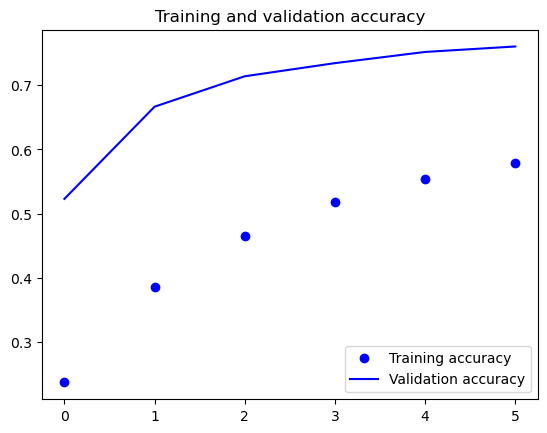

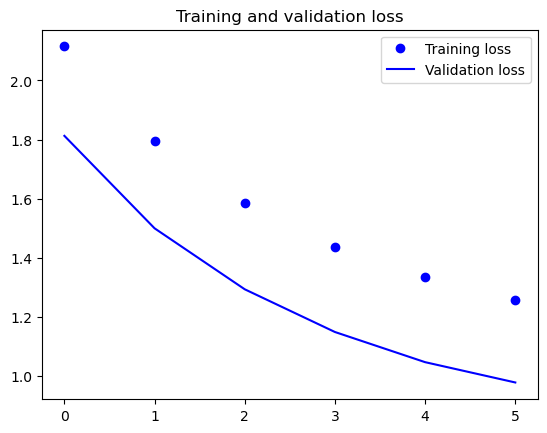

In [113]:
accuracy = sport_train.history['accuracy']
val_accuracy = sport_train.history['val_accuracy']
loss = sport_train.history['loss']
val_loss = sport_train.history['val_loss']

epochs = range(len(accuracy))

# Gráfico de accuracy
plt.plot(epochs, accuracy, 'bo', label='Training accuracy')
plt.plot(epochs, val_accuracy, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend()

plt.figure()

# Gráfico de loss
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()

plt.show()


In [118]:
predicted_classes2 = sport_model.predict(test_X)

483/483 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [119]:
predicted_classes = []

for predicted_sport in predicted_classes2:
    predicted_classes.append(predicted_sport.tolist().index(max(predicted_sport)))

predicted_classes = np.array(predicted_classes)


In [116]:
predicted_classes.shape, test_Y.shape

((15426,), (15426,))

### 11 Aprendamos de los errores: Qué mejorar

In [126]:
correct = np.where(predicted_classes == test_Y)[0]
print("Found %d correct labels" % len(correct))

for i, correct_idx in enumerate(correct[0:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_X[correct_idx].reshape(21, 28, 3), cmap='gray',
               interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[correct_idx]], 
                              deportes[test_Y[correct_idx]]))

plt.tight_layout()


Found 11718 correct labels


In [127]:
incorrect = np.where(predicted_classes != test_Y)[0]
print("Found %d incorrect labels" % len(incorrect))

for i, incorrect_idx in enumerate(incorrect[0:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(test_X[incorrect_idx].reshape(21, 28, 3), cmap='gray', interpolation='none')
    plt.title("{}, {}".format(deportes[predicted_classes[incorrect_idx]], 
                             deportes[test_Y[incorrect_idx]]))

plt.tight_layout()


Found 3708 incorrect labels


In [128]:
target_names = ["Class{}".format(i) for i in range(nClasses)]
print(classification_report(test_Y, predicted_classes, target_names=target_names))


              precision    recall  f1-score   support

      Class0       0.54      0.47      0.51      1917
      Class1       0.74      0.83      0.78      1800
      Class2       0.75      0.70      0.72      1496
      Class3       0.75      0.83      0.79      1456
      Class4       0.94      0.99      0.96      1500
      Class5       0.82      0.18      0.29      1034
      Class6       0.89      0.77      0.83      1458
      Class7       0.59      0.86      0.70      1994
      Class8       0.89      0.80      0.84      1014
      Class9       0.95      1.00      0.97      1757

    accuracy                           0.76     15426
   macro avg       0.79      0.74      0.74     15426
weighted avg       0.77      0.76      0.75     15426



### 12 Predicciondeunanuevaimagen

In [134]:
from skimage.transform import resize

images = []

# Aquí especificamos unas imágenes
filenames = ['sportimages/golf/golf_0113.jpg']

for filepath in filenames:
    image = plt.imread(filepath, 0)
    image_resized = resize(
        image,
        (21, 28),
        anti_aliasing=True,
        clip=False,
        preserve_range=True
    )
    images.append(image_resized)

X = np.array(images, dtype=np.uint8)  # convierto de lista a numpy
test_X = X.astype('float32')
test_X = test_X / 255.

predicted_classes = sport_model.predict(test_X)

for i, img_tagged in enumerate(predicted_classes):
    print(filenames[i], deportes[img_tagged.tolist().index(max(img_tagged))])


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 882ms/step
sportimages/golf/golf_0113.jpg futbol


[Repositorio Tercer parcial](https://github.com/HLuiss17/Pr-cticas_Aprendizajee_Autom-tico_2/tree/master/segundoParcial)